<a href="https://colab.research.google.com/github/YoungSong99/CSC578-Final-Project/blob/main/csc578_FinalProject_VAE_vs_Deterministic_Autoencoder_Pokemon_Sprites_Assignment_Template.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# VAE vs Deterministic Autoencoder using Pokémon Sprites




## Part 0. Introduction

### Temporary Team Work Division (Delete Before Final Release)
#### Person 1 Ownership (Carlos)
- Data loading
- Preprocessing
- Deterministic Autoencoder implementation and training
- Reconstruction plotting for AE and VAE
- Notebook structure and section flow

#### Person 2 Ownership (James)
- Variational Autoencoder implementation and training
- KL divergence/loss integration
- Latent sampling
- Interpolation

#### Person 3 Ownership (Young)
- Baseline AE vs VAE comparison
- Synthetic comparison results scaffolding
- Latent exploration/disentanglement section
- Analysis/reflection questions
- Grading rubric
- Final integration and consistency review
- Answer key creation and maintenance

### Placeholder Note
- The cells below are assignment placeholders for completion.
- You may modify existing cells and add more cells as needed.
- Edit as needed.


In [ ]:
# TODO (Person 3): add title-adjacent notebook metadata placeholders (edit as needed)
# TODO (Person 3): add team-version marker for draft tracking (edit as needed)

### Learning Objectives

TODO (Person 3): write learning objectives (edit as needed)
TODO (Person 3): align objectives with Parts 1–9 deliverables (edit as needed)

In [ ]:
# TODO (Person 3): add objective-checkpoint placeholders (edit as needed)
# TODO (Person 3): add objective-to-section mapping comments (edit as needed)

### Background / Key Concepts

TODO (Person 2): draft key concepts for AE, VAE, KL divergence, and latent variables (edit as needed)
TODO (Person 2): define concept boundaries required for assignment completion (edit as needed)

In [ ]:
# TODO (Person 2): add concept-check prompts and placeholder equations (edit as needed)
# TODO (Person 2): add placeholder notation block for KL and reconstruction terms (edit as needed)

### Setup

TODO (Person 3): define setup expectations and ownership boundaries (edit as needed)
TODO (Person 3): add setup validation checklist placeholders (edit as needed)

In [ ]:
# TODO (Person 1): add dependency and environment setup steps (edit as needed)
# TODO (Person 1): add runtime/device check placeholders (edit as needed)

### Global Configuration

TODO (Person 3): define global constants and experiment settings checklist (edit as needed)
TODO (Person 3): add seed/reproducibility TODO placeholders (edit as needed)

In [ ]:
# TODO (Person 1): add configuration variables for data, model, and training (edit as needed)
# TODO (Person 1): add placeholder toggles for AE and VAE experiment modes (edit as needed)

## Part 1: Load and Explore Dataset

TODO (Person 1): create dataset loading and exploration tasks (edit as needed)
TODO (Person 1): add dataset split and integrity TODO checkpoints (edit as needed)

In [ ]:
# TODO (Person 1): implement dataset loading pipeline for Pokémon sprites (edit as needed)
# TODO (Person 1): add basic dataset integrity checks (edit as needed)
# TODO (Person 1): add preprocessing checkpoint placeholders before model training (edit as needed)

# TODO (Person 1): implement dataset loading pipeline for Pokémon sprites (edit as needed)
# TODO (Person 1): add basic dataset integrity checks (edit as needed)
# TODO (Person 1): add preprocessing checkpoint placeholders before model training (edit as needed)

# https://www.kaggle.com/datasets/yehongjiang/pokemon-sprites-images

import os
import json
from kaggle.api.kaggle_api_extended import KaggleApi
from google.colab import userdata

# Retrieve Kaggle credentials from Colab secrets
kaggle_username = userdata.get("KAGGLE_USERNAME")
kaggle_key = userdata.get("KAGGLE_API_KEY")

print("KAGGLE_USERNAME:", kaggle_username)
print("KAGGLE_API_KEY exists:", kaggle_key is not None)

if not kaggle_username or not kaggle_key:
    raise ValueError(
        "Missing Kaggle credentials. Add KAGGLE_USERNAME and KAGGLE_API_KEY to Colab secrets."
    )

# Set environment variables for Kaggle API
os.environ["KAGGLE_USERNAME"] = kaggle_username
os.environ["KAGGLE_KEY"] = kaggle_key

# Also write kaggle.json since this is the most reliable auth path in Colab
kaggle_dir = os.path.expanduser("~/.kaggle")
os.makedirs(kaggle_dir, exist_ok=True)

kaggle_json_path = os.path.join(kaggle_dir, "kaggle.json")
with open(kaggle_json_path, "w") as f:
    json.dump({
        "username": kaggle_username,
        "key": kaggle_key
    }, f)

os.chmod(kaggle_json_path, 0o600)

# Initialize and authenticate the Kaggle API
api = KaggleApi()
api.authenticate()

# Download the dataset
dataset_path = "yehongjiang/pokemon-sprites-images"
download_dir = "./pokemon_sprites_data"

os.makedirs(download_dir, exist_ok=True)
api.dataset_download_files(dataset_path, path=download_dir, unzip=True)

print(f"Dataset downloaded and extracted to: {download_dir}")

# check files, folder size and count includes subdirectories
file_count = sum(len(files) for _, _, files in os.walk(download_dir))
folder_count = sum(os.path.isdir(os.path.join(download_dir, name)) for name in os.listdir(download_dir))

if file_count == 0:
  print("No files found in the directory.")
else:
  print(f"Total number of files: {file_count}")


=== Enter Kaggle Credentials ===
Enter your KAGGLE_USERNAME: youngsong99
Enter your KAGGLE_API_KEY (input will be hidden): ··········

KAGGLE_USERNAME: youngsong99
KAGGLE_API_KEY exists: True


SecretNotFoundError: Secret KAGGLE_USERNAME does not exist.

In [ ]:
# @title
# TODO (Person 1): implement dataset loading pipeline for Pokémon sprites (edit as needed)
# TODO (Person 1): add basic dataset integrity checks (edit as needed)
# TODO (Person 1): add preprocessing checkpoint placeholders before model training (edit as needed)

# https://www.kaggle.com/datasets/yehongjiang/pokemon-sprites-images

import os
import json
import urllib.request
import ipywidgets as widgets
from IPython.display import display, clear_output
from kaggle.api.kaggle_api_extended import KaggleApi

# ── Fetch Pokémon image ───────────────────────────────────────────────────────
poke_img_data = urllib.request.urlopen(
    "https://raw.githubusercontent.com/PokeAPI/sprites/master/sprites/pokemon/other/official-artwork/25.png"
).read()

# ── Left panel ────────────────────────────────────────────────────────────────
left_panel = widgets.VBox(
    [
        widgets.Image(value=poke_img_data, format="png", width=140, height=140),
        widgets.HTML("""
            <div style="text-align:center; padding: 12px 16px;">
                <h3 style="margin: 8px 0 4px;">📦 Pokémon Sprites</h3>
                <p style="margin: 4px 0;">
                    <a href="https://www.kaggle.com/datasets/yehongjiang/pokemon-sprites-images" target="_blank">
                        View on Kaggle
                    </a>
                </p>
                <hr style="margin: 10px 0;"/>
                <p style="margin: 4px 0; font-size:13px;">
                    Enter your credentials on the right,<br/>then click <b>Download Dataset</b>.
                </p>
                <p style="margin: 8px 0 0; font-size:11px; color:gray;">
                    No API key? Go to<br/>
                    kaggle.com → Account → Create New Token
                </p>
            </div>
        """),
    ],
    layout=widgets.Layout(
        align_items="center",
        justify_content="center",
        border="1px solid #ddd",
        border_radius="10px",
        padding="16px",
        min_width="260px",
        min_height="320px",
    ),
)

# ── Right panel ───────────────────────────────────────────────────────────────
username_input = widgets.Text(
    placeholder="Enter your Kaggle username",
    description="USERNAME:",
    layout=widgets.Layout(width="380px"),
)

apikey_input = widgets.Password(
    placeholder="Enter your Kaggle API key",
    description="API KEY:",
    layout=widgets.Layout(width="380px"),
)

run_button = widgets.Button(
    description="Download Dataset",
    button_style="primary",
    icon="download",
    layout=widgets.Layout(width="200px"),
)

output = widgets.Output()

right_panel = widgets.VBox(
    [username_input, apikey_input, run_button, output],
    layout=widgets.Layout(
        align_items="flex-start",
        justify_content="center",
        border="1px solid #ddd",
        border_radius="10px",
        padding="24px 20px",
        min_width="420px",
        min_height="320px",
    ),
)

# ── Combined UI ───────────────────────────────────────────────────────────────
ui = widgets.HBox(
    [left_panel, right_panel],
    layout=widgets.Layout(gap="16px", align_items="stretch"),
)
display(ui)

def on_run_clicked(b):
    with output:
        clear_output()

        kaggle_username = username_input.value.strip()
        kaggle_key      = apikey_input.value.strip()

        if not kaggle_username or not kaggle_key:
            print("❌ Please fill in both USERNAME and API KEY.")
            return

        # Write kaggle.json
        kaggle_dir = os.path.expanduser("~/.kaggle")
        os.makedirs(kaggle_dir, exist_ok=True)
        kaggle_json_path = os.path.join(kaggle_dir, "kaggle.json")
        with open(kaggle_json_path, "w") as f:
            json.dump({"username": kaggle_username, "key": kaggle_key}, f)
        os.chmod(kaggle_json_path, 0o600)

        # Set env vars explicitly before authenticate()
        os.environ["KAGGLE_USERNAME"] = kaggle_username
        os.environ["KAGGLE_KEY"]      = kaggle_key

        try:
            api = KaggleApi()
            api.authenticate()
            print("Kaggle API authentication successful!")
        except (Exception, SystemExit) as e:
            print(f"Authentication failed: {e}")
            return

        dataset_path = "yehongjiang/pokemon-sprites-images"
        download_dir = "./pokemon_sprites_data"
        os.makedirs(download_dir, exist_ok=True)

        print(f"Downloading '{dataset_path}'...")
        try:
            api.dataset_download_files(dataset_path, path=download_dir, unzip=True)
        except (Exception, SystemExit) as e:
            print(f"Download failed: {e}")
            return

        print(f"Dataset downloaded and extracted to: {download_dir}")

        file_count   = sum(len(files) for _, _, files in os.walk(download_dir))
        folder_count = sum(
            os.path.isdir(os.path.join(download_dir, name))
            for name in os.listdir(download_dir)
        )

        print(f"📁 Total files : {file_count}")

run_button.on_click(on_run_clicked)

## Part 2: Data Visualization

TODO (Person 1): define visualization tasks for sprite samples and distributions (edit as needed)
TODO (Person 1): define comparison-ready visualization outputs for downstream sections (edit as needed)

Found 10177 images


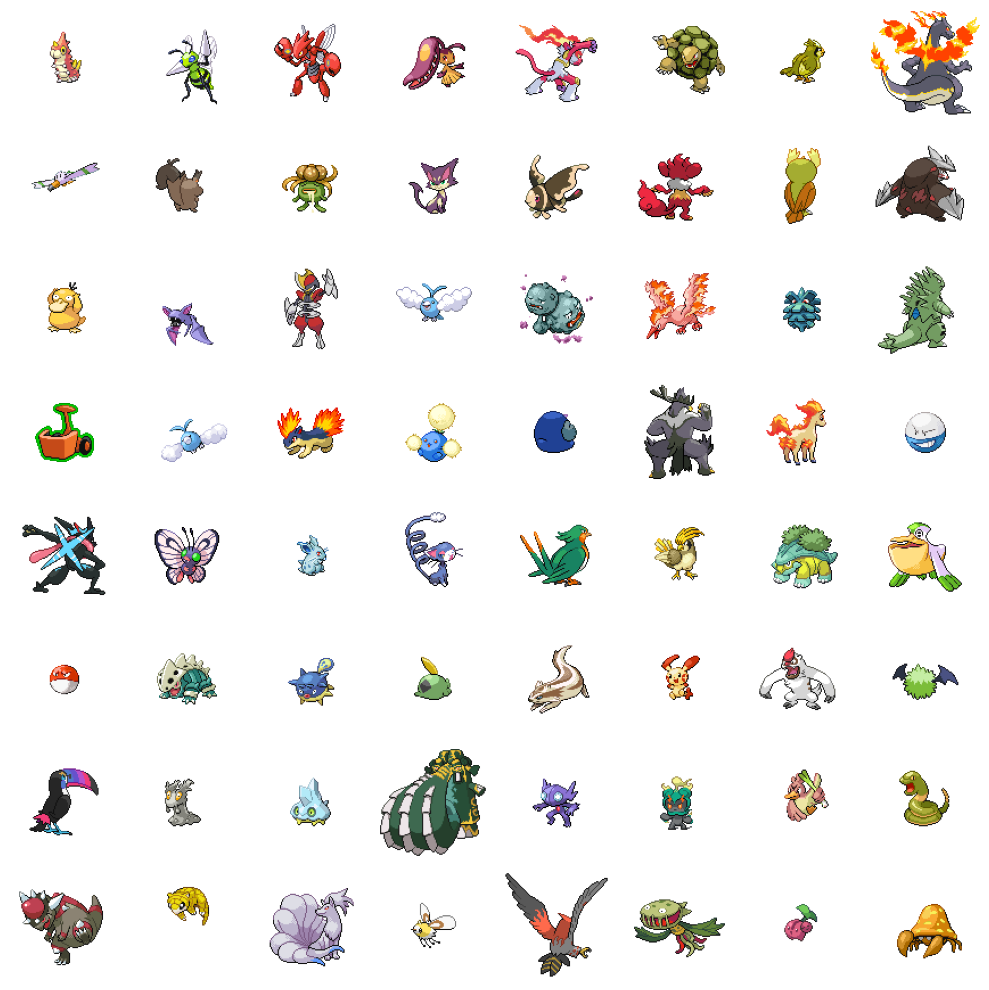

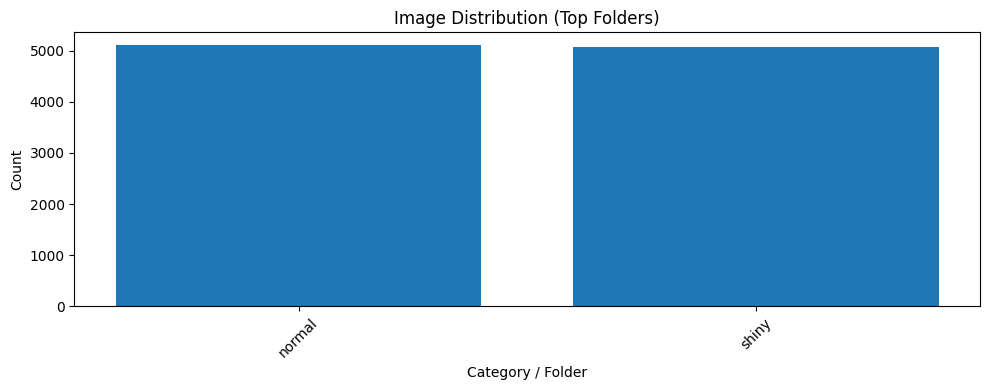

In [ ]:
# TODO (Person 1): implement sample grid and class/distribution visualizations (edit as needed)
# TODO (Person 1): add visualization sanity-check placeholders (edit as needed)

# TODO (Person 1): implement sample grid and class/distribution visualizations (edit as needed)
# TODO (Person 1): add visualization sanity-check placeholders (edit as needed)

# implement sample grid and class/distribution visualizations using matplotlib
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

# assume images are inside this directory (update if needed)
data_dir = "./pokemon_sprites_data"

# collect image file paths
image_paths = []
for root, _, files in os.walk(data_dir):
    for f in files:
        if f.lower().endswith((".png", ".jpg", ".jpeg")):
            image_paths.append(os.path.join(root, f))

print(f"Found {len(image_paths)} images")

# ---------------------------
# Sample Grid Visualization
# ---------------------------

num_rows = 8
num_cols = 8

fig, axes = plt.subplots(num_rows, num_cols, figsize=(10, 10))

# randomly sample images
sample_paths = np.random.choice(image_paths, num_rows * num_cols, replace=False)

for i, ax in enumerate(axes.flatten()):
    img = Image.open(sample_paths[i]).convert("RGBA")
    ax.imshow(img)
    ax.axis("off")

plt.tight_layout()
plt.show()

# ---------------------------
# Distribution Visualization
# ---------------------------
# simple proxy: count images per folder (since labels may not exist)

from collections import Counter

folder_names = [os.path.basename(os.path.dirname(p)) for p in image_paths]
counts = Counter(folder_names)

# take top 10 for readability
top_items = counts.most_common(10)

labels = [x[0] for x in top_items]
values = [x[1] for x in top_items]

plt.figure(figsize=(10, 4))
plt.bar(labels, values)
plt.xticks(rotation=45)
plt.title("Image Distribution (Top Folders)")
plt.xlabel("Category / Folder")
plt.ylabel("Count")
plt.tight_layout()
plt.show()



## Part 3: Build and Train Autoencoder

TODO (Person 1): outline deterministic autoencoder architecture and training tasks (edit as needed)
TODO (Person 1): define AE evaluation checkpoints and training logs TODOs (edit as needed)

In [ ]:
# TODO (Person 1): implement deterministic autoencoder model (edit as needed)
# TODO (Person 1): implement training loop and logging (edit as needed)
# TODO (Person 1): add AE checkpoint save/load placeholders (edit as needed)

## Part 4: Build and Train Variational Autoencoder

TODO (Person 2): outline VAE encoder-decoder, latent params, and training tasks (edit as needed)
TODO (Person 2): define KL/reconstruction balancing TODO checkpoints (edit as needed)

In [ ]:
# TODO (Person 2): implement VAE architecture and reparameterization sampling (edit as needed)
# TODO (Person 2): implement reconstruction plus KL loss training (edit as needed)
# TODO (Person 2): add KL-weight tuning placeholder hooks (edit as needed)

## Part 5: Reconstruction Comparison (AE vs VAE)

TODO (Person 1): define side-by-side reconstruction comparison tasks for both models (edit as needed)
TODO (Person 3): define synthetic baseline comparison placeholders for interim analysis (edit as needed)
TODO (Person 3): define replacement plan from synthetic placeholders to real metrics (edit as needed)

### Example Outputs (Template Placeholder)
- AE Output Example: original sprite → reconstructed sprite with sharper edges and lower variation (synthetic placeholder)
- VAE Output Example: original sprite → reconstructed sprite with smoother textures and slight blur (synthetic placeholder)
- Comparison Example: AE reconstruction loss placeholder = [TBD], VAE reconstruction+KL loss placeholder = [TBD]
- Figure Example: 3-row grid [Original | AE Recon | VAE Recon] for N sample sprites

In [ ]:
# TODO (Person 1): implement reconstruction plotting for AE and VAE (edit as needed)
# TODO (Person 3): add synthetic baseline metric comparison placeholders (edit as needed)
# TODO (Person 3): add placeholder-to-real-output switch comments (edit as needed)

## Part 6: Latent Sampling (VAE)

TODO (Person 2): define latent sampling tasks and expected generated sprite outputs (edit as needed)
TODO (Person 2): define sampling checkpoint placeholders for qualitative review (edit as needed)

In [ ]:
# TODO (Person 2): implement latent prior sampling and decoding (edit as needed)
# TODO (Person 2): add sample-grid placeholder output checks (edit as needed)

## Part 7: Latent Interpolation

TODO (Person 2): define interpolation procedure and comparison tasks (edit as needed)
TODO (Person 2): define interpolation endpoint selection criteria TODOs (edit as needed)

In [ ]:
# TODO (Person 2): implement latent interpolation between selected samples (edit as needed)
# TODO (Person 2): add interpolation figure placeholder checkpoints (edit as needed)

## Part 8: Latent Space Exploration (Optional / Disentanglement)

TODO (Person 3): define optional disentanglement exploration tasks (edit as needed)
TODO (Person 3): define optional synthetic latent traversal placeholders for integration testing (edit as needed)

In [ ]:
# TODO (Person 3): implement latent traversal and factor-variation probes

## Part 9: Analysis / Reflection Questions

TODO (Person 3): write analysis and reflection questions for student responses (edit as needed)
TODO (Person 3): map each question to one expected output artifact (edit as needed)

In [ ]:
# TODO (Person 3): add response placeholder prompts for analysis questions

## Expected Outputs

TODO (Person 3): define expected output checkpoints for each part (edit as needed)
TODO (Person 3): add synthetic expected comparison outputs for placeholder workflow (edit as needed)

In [ ]:
# TODO (Person 3): add expected-output validation checkpoints (edit as needed)
# TODO (Person 3): add synthetic result table/plot placeholders for interim checks (edit as needed)

## Grading Rubric

TODO (Person 3): write grading rubric with point breakdown and ownership (edit as needed)
TODO (Person 3): align rubric criteria with Part 1–9 deliverables (edit as needed)

In [ ]:
# TODO (Person 3): add rubric table placeholder generation comments (edit as needed)
# TODO (Person 3): finalize integration checklist across all team sections (edit as needed)
# TODO (Person 3): add final consistency pass placeholders before release (edit as needed)